# Assignment 5: Exploring the Latent Space of a Pretrained StyleGAN2 Model
**Name:** Prakruthi BR  
**Course:** BCA  
**Subject:** Generative AI

## Objective

The objective of this assignment is to understand how changes in the latent space of a pretrained StyleGAN2 model affect generated images.

In this experiment, we will:
- Load a pretrained StyleGAN2 model.
- Generate two random latent vectors, Z1 and Z2.
- Generate and save two images using Z1 and Z2.
- Perform linear interpolation between Z1 and Z2.
- Generate around 10 intermediate latent vectors and images.
- Create a single image strip showing the smooth transition.
- Generate the same image again using the original latent vector.
- Compare the original and regenerated images.
- Change one or two latent dimensions and observe the visual changes.
- Write observations and a conclusion.

## 1. Enable GPU

Google Colab provides GPU support, which makes generating images using the StyleGAN2 model faster.

We will first check whether a GPU is available.

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


### Explanation

The `torch.cuda.is_available()` function checks whether a CUDA-enabled GPU is available.

- If a GPU is available, the model will use `cuda`.
- Otherwise, the model will use the CPU.

Using a GPU is recommended because StyleGAN2 performs many mathematical operations while generating an image.

## 2. Download the StyleGAN2-ADA Repository

StyleGAN2-ADA is a pretrained generative adversarial network architecture developed by NVIDIA.

We will download the official StyleGAN2-ADA implementation so that we can load and use a pretrained model without training it from scratch.

In [2]:
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git

Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 1.45 MiB/s, done.
Resolving deltas: 100% (57/57), done.


### Explanation

The `git clone` command downloads the StyleGAN2-ADA source code from GitHub into the Google Colab environment.

We are using the pretrained implementation because this assignment is about exploring the latent space, not training StyleGAN2 from scratch.

## 3. Install Required Packages

The StyleGAN2 repository requires some Python packages for model loading and image generation.

In [3]:
!pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 893.7 kB/s eta 0:00:00


### Explanation

`ninja` is used by some of the StyleGAN2 components to compile and run operations efficiently.

Installing it helps the StyleGAN2 implementation work correctly in Google Colab.

## 4. Download the Pretrained StyleGAN2 Model

For this experiment, we use a pretrained StyleGAN2 model trained on the FFHQ face dataset.

FFHQ stands for Flickr-Faces-HQ and contains high-quality human face images.

We do not train the model ourselves. We only use the already-trained generator.

In [4]:
!wget -O /content/stylegan2-ffhq.pkl \
https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl

--2026-09-26 16:07:20--  https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl
Resolving nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)... 13.35.36.51, 13.35.36.38, 13.35.36.74, ...
Connecting to nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)|13.35.36.51|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381624121 (364M) [binary/octet-stream]
Saving to: ‘/content/stylegan2-ffhq.pkl’

/content/stylegan2- 100%[===================>] 363.94M  19.1MB/s    in 20s     

2026-09-26 16:07:41 (17.9 MB/s) - ‘/content/stylegan2-ffhq.pkl’ saved [381624121/381624121]



### Explanation

The `wget` command downloads the pretrained StyleGAN2 model.

The downloaded file is:

`stylegan2-ffhq.pkl`

The `.pkl` file contains the pretrained StyleGAN2 network that will be used to generate images.

## 5. Import Required Libraries

We now import the Python libraries required for loading the model, creating latent vectors, generating images, displaying results, and saving the output images.

In [5]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from PIL import Image

# Add the StyleGAN2 repository to the Python path
sys.path.append("/content/stylegan2-ada-pytorch")

import legacy

### Explanation

The main libraries used in this experiment are:

- `numpy` – used to create and manipulate latent vectors.
- `torch` – used to load and run the StyleGAN2 model.
- `matplotlib` – used to display generated images.
- `imageio` – used to save generated images.
- `PIL` – used for image processing and creating the optional GIF.
- `os` – used for creating folders and managing files.
- `legacy` – provided by StyleGAN2-ADA and used to load the pretrained model.

The StyleGAN2 repository is added to Python's path so that its modules can be imported.

## 6. Load the Pretrained StyleGAN2 Generator

The pretrained model is stored in a `.pkl` file.

We will load the generator from this file and move it to the available device.

The generator is responsible for converting a latent vector into an image.

In [6]:
network_pkl = "/content/stylegan2-ffhq.pkl"

with open(network_pkl, "rb") as f:
    G = legacy.load_network_pkl(f)["G_ema"].to(device)

G.eval()

print("StyleGAN2 model loaded successfully.")

StyleGAN2 model loaded successfully.


### Explanation

The model file is opened using Python's `open()` function.

`legacy.load_network_pkl()` loads the pretrained StyleGAN2 network.

`G_ema` represents the generator used for high-quality image generation.

The `.to(device)` operation moves the model to the GPU if a GPU is available.

`G.eval()` places the generator in evaluation mode because we are generating images rather than training the model.

## 7. Check the Latent Vector Dimension

StyleGAN2 uses a latent vector as input to the generator.

For the pretrained FFHQ model, the latent vector contains 512 numerical values.

In [7]:
z_dim = G.z_dim

print("Latent vector dimension:", z_dim)

Latent vector dimension: 512


### Explanation

`G.z_dim` gives the dimensionality of the latent space accepted by the generator.

For this pretrained FFHQ StyleGAN2 model, the output should be:

`Latent vector dimension: 512`

Therefore, each random latent vector contains 512 values.

## 8. Create a Folder for Assignment Results

All generated images will be saved in one folder so that they can easily be downloaded and submitted later.

In [8]:
results_dir = "/content/stylegan_results"

os.makedirs(results_dir, exist_ok=True)

print("Results folder created:", results_dir)

Results folder created: /content/stylegan_results


### Explanation

`os.makedirs()` creates a folder called `stylegan_results`.

The `exist_ok=True` option prevents an error if the folder already exists.

All important output images will be stored in this folder.

## 9. Generate Two Random Latent Vectors

We now generate two random latent vectors called `Z1` and `Z2`.

Each vector contains 512 values.

These two vectors will be used to generate two different images.

In [9]:
np.random.seed(42)

Z1 = np.random.randn(1, z_dim).astype(np.float32)
Z2 = np.random.randn(1, z_dim).astype(np.float32)

print("Z1 shape:", Z1.shape)
print("Z2 shape:", Z2.shape)

Z1 shape: (1, 512)
Z2 shape: (1, 512)


### Explanation

`np.random.randn()` generates random values from a normal distribution.

The shape `(1, 512)` means:

- `1` = one latent vector
- `512` = 512 latent dimensions

The random seed `42` is used so that the same random latent vectors can be reproduced if the notebook is run again.

## 10. Convert Z1 and Z2 into PyTorch Tensors

StyleGAN2 uses PyTorch tensors as input.

Therefore, the NumPy latent vectors are converted into PyTorch tensors and moved to the same device as the generator.

In [10]:
z1 = torch.from_numpy(Z1).to(device)
z2 = torch.from_numpy(Z2).to(device)

print("Z1 tensor shape:", z1.shape)
print("Z2 tensor shape:", z2.shape)

Z1 tensor shape: torch.Size([1, 512])
Z2 tensor shape: torch.Size([1, 512])


### Explanation

`torch.from_numpy()` converts the NumPy arrays into PyTorch tensors.

`.to(device)` moves the tensors to the GPU if CUDA is available.

The dimensions remain `(1, 512)`.

## 11. Generate the First Image Using Z1

The first latent vector, `Z1`, is passed to the pretrained StyleGAN2 generator.

The generator transforms the numerical latent representation into a realistic face image.

In [11]:
with torch.no_grad():
    output1 = G(z1, None)

img1 = (output1.clamp(-1, 1) * 127.5 + 127.5).to(torch.uint8)

img1 = img1[0].permute(1, 2, 0).cpu().numpy()

print("Generated image shape:", img1.shape)

Setting up PyTorch plugin "bias_act_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/bias_act.py:50: UserWarning: Failed to build CUDA kernels for bias_act. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/bias_act.py", line 48, in _init
    _plugin = custom_ops.get_plugin('bias_act_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module 

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Generated image shape: (1024, 1024, 3)


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

### Explanation

`torch.no_grad()` tells PyTorch that gradients are not required because we are only generating an image.

The StyleGAN2 output is converted from its normalized range into standard image pixel values.

`permute(1, 2, 0)` changes the image format from:

`Channels × Height × Width`

to:

`Height × Width × Channels`

This makes the image compatible with Matplotlib and image-saving libraries.

## 12. Display the Image Generated from Z1

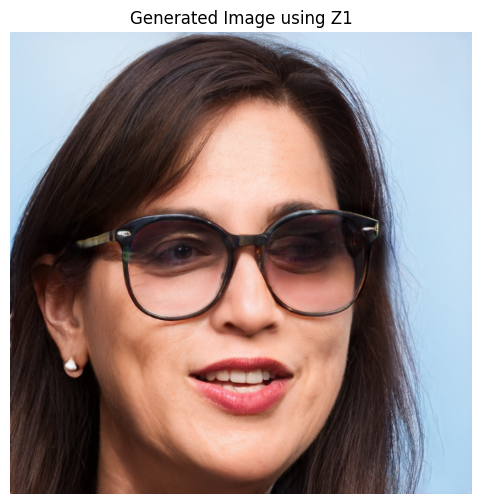

In [12]:
plt.figure(figsize=(6, 6))
plt.imshow(img1)
plt.axis("off")
plt.title("Generated Image using Z1")
plt.show()

### Explanation

Matplotlib is used to display the generated image.

This is the first original generated image required for the assignment.

## 13. Save the First Generated Image

The image generated using `Z1` is saved as a PNG file.

In [13]:


imageio.imwrite(
    f"{results_dir}/image_Z1.png",
    img1
)

print("Z1 image saved successfully.")

Z1 image saved successfully.


### Explanation

`imageio.imwrite()` saves the generated image as a PNG file.

The saved file is:

`image_Z1.png`

This image will be included in the final assignment submission.

## 14. Generate the Second Image Using Z2

We now use the second random latent vector, `Z2`, to generate another image.

Because `Z2` is different from `Z1`, the generated image should have a different appearance.

In [14]:
with torch.no_grad():
    output2 = G(z2, None)

img2 = (output2.clamp(-1, 1) * 127.5 + 127.5).to(torch.uint8)

img2 = img2[0].permute(1, 2, 0).cpu().numpy()

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

### Explanation

The same pretrained StyleGAN2 generator is used again.

The only major difference is the input latent vector.

This demonstrates that changing the latent vector can result in a different generated image.

## 15. Display the Image Generated from Z2

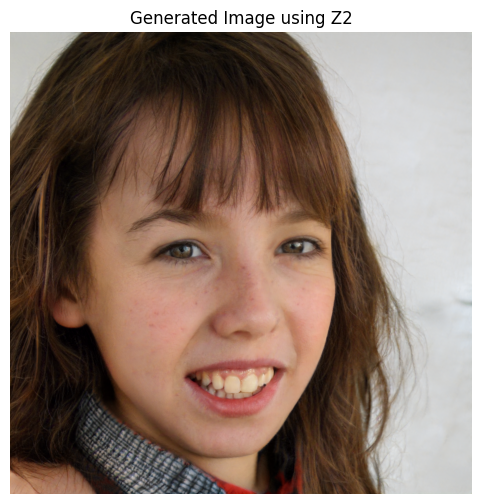

In [15]:
plt.figure(figsize=(6, 6))
plt.imshow(img2)
plt.axis("off")
plt.title("Generated Image using Z2")
plt.show()

## 16. Save the Second Generated Image

In [16]:
imageio.imwrite(
    f"{results_dir}/image_Z2.png",
    img2
)

print("Z2 image saved successfully.")

Z2 image saved successfully.


### Explanation

The second generated image is saved as:

`image_Z2.png`

We now have the two original images required by the assignment.

## 17. Compare the Images Generated from Z1 and Z2

The two images are displayed side by side to observe the differences produced by the two random latent vectors.

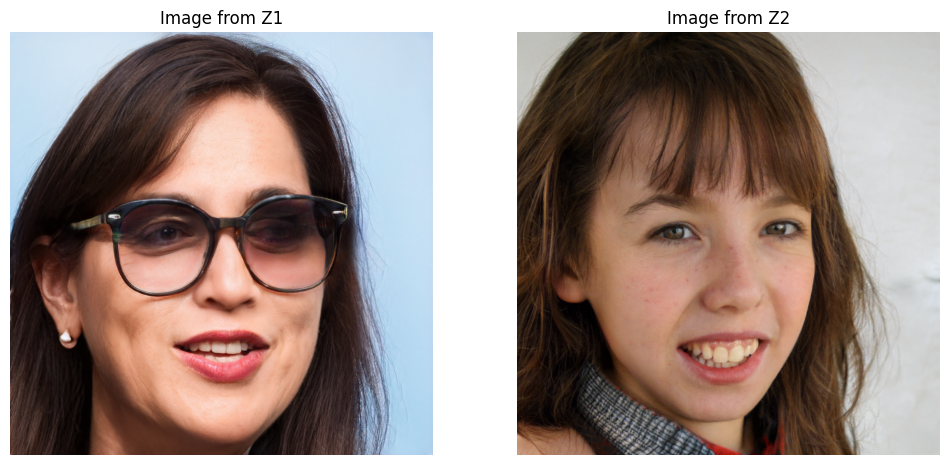

In [17]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.axis("off")
plt.title("Image from Z1")

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.axis("off")
plt.title("Image from Z2")

plt.show()

### Explanation

The two images are displayed next to each other.

Since `Z1` and `Z2` are different points in the latent space, the generated faces can have different visual characteristics.

## 18. Linear Interpolation Between Z1 and Z2

Instead of directly changing from `Z1` to `Z2`, we create intermediate latent vectors.

Linear interpolation is given by:

Z(t) = (1 - t)Z1 + tZ2

where:

- `t = 0` gives Z1.
- `t = 1` gives Z2.
- Values between 0 and 1 produce intermediate latent vectors.

We will generate 10 latent vectors, including the starting and ending vectors.

In [18]:
num_steps = 10

alphas = np.linspace(0, 1, num_steps)

interpolated_latents = []

for alpha in alphas:
    z_interpolated = (1 - alpha) * Z1 + alpha * Z2
    interpolated_latents.append(z_interpolated)

interpolated_latents = np.concatenate(
    interpolated_latents,
    axis=0
)

print("Interpolated latent vectors shape:",
      interpolated_latents.shape)

Interpolated latent vectors shape: (10, 512)


### Explanation

`np.linspace(0, 1, 10)` creates 10 equally spaced interpolation values.

For each value of `alpha`, a new latent vector is calculated using:

`(1 - alpha) * Z1 + alpha * Z2`

The first vector is exactly `Z1`.

The last vector is exactly `Z2`.

The remaining eight vectors are points between them.

The final shape is `(10, 512)`, meaning that we have 10 latent vectors and each contains 512 dimensions.

## 19. Generate Images from the Interpolated Latent Vectors

The 10 interpolated latent vectors are now passed through the StyleGAN2 generator.

This produces 10 images showing the transition from the first generated face to the second generated face.

In [19]:
z_interpolated = torch.from_numpy(
    interpolated_latents
).to(device)

with torch.no_grad():
    interpolation_output = G(
        z_interpolated,
        None
    )

interpolation_images = (
    interpolation_output.clamp(-1, 1) * 127.5 + 127.5
).to(torch.uint8)

interpolation_images = (
    interpolation_images
    .permute(0, 2, 3, 1)
    .cpu()
    .numpy()
)

print("Number of generated images:",
      len(interpolation_images))

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Failed!
Number of generated images: 10


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

### Explanation

All 10 latent vectors are passed to the generator.

The generator produces 10 corresponding images.

The resulting data contains:

`10 images × height × width × RGB channels`

The first image corresponds to `Z1` and the final image corresponds to `Z2`.

## 20. Display the 10 Interpolated Images

The generated images are displayed together so that the visual transition can be observed.

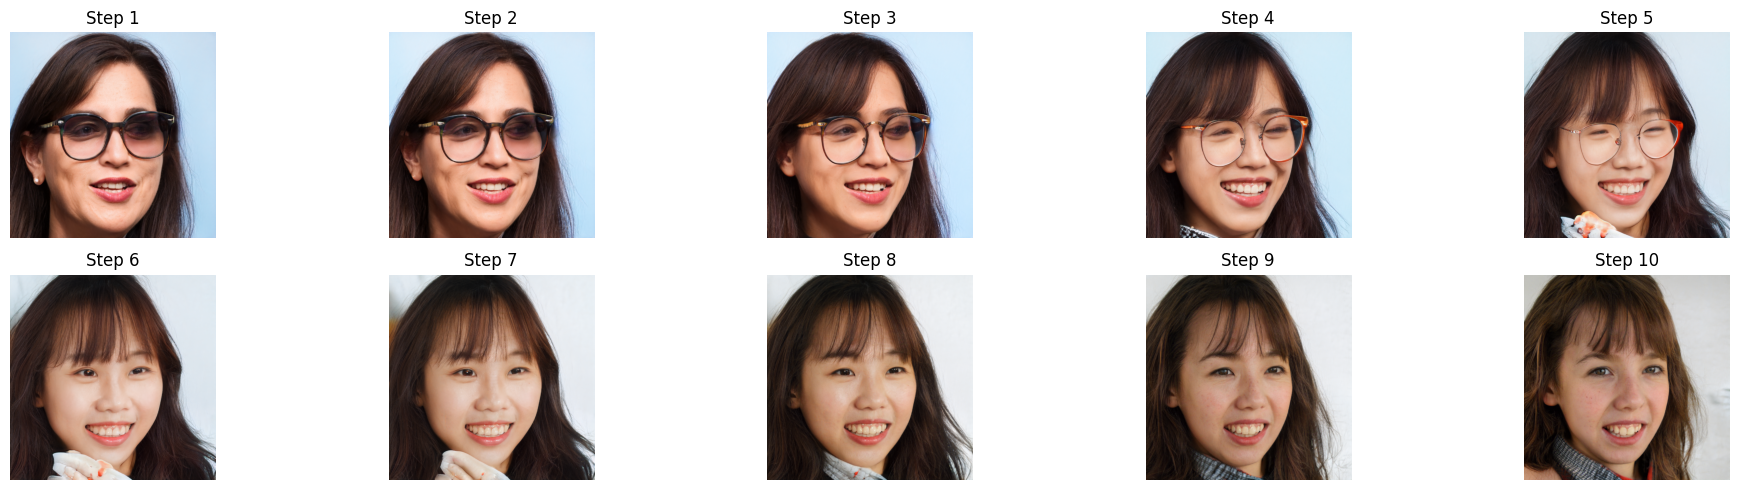

In [20]:
plt.figure(figsize=(20, 5))

for i in range(num_steps):
    plt.subplot(2, 5, i + 1)
    plt.imshow(interpolation_images[i])
    plt.axis("off")
    plt.title(f"Step {i + 1}")

plt.tight_layout()
plt.show()

### Explanation

The 10 images are arranged in two rows.

The first image represents `Z1`.

The last image represents `Z2`.

The images between them represent intermediate positions in the latent space.

We expect to see a gradual rather than sudden visual transition.

In [21]:
for i, image in enumerate(interpolation_images):
    filename = f"{results_dir}/interpolation_{i+1:02d}.png"
    imageio.imwrite(filename, image)

print("All 10 interpolation images saved successfully.")

All 10 interpolation images saved successfully.


### Explanation

The loop goes through all 10 generated images.

Each image receives a separate filename such as:

- interpolation_01.png
- interpolation_02.png
- interpolation_03.png
- ...
- interpolation_10.png

## 22. Create a Single Image Strip

The assignment requires a single image strip showing the smooth transition between the two original images.

The 10 generated images will be joined horizontally.

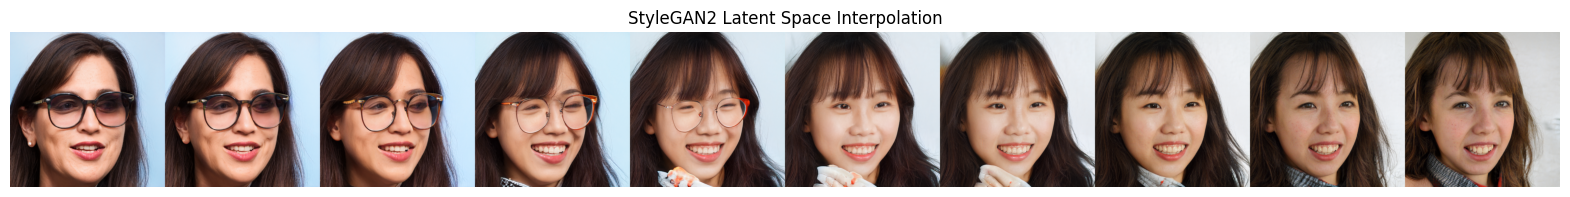

In [22]:
image_strip = np.concatenate(
    interpolation_images,
    axis=1
)

plt.figure(figsize=(20, 4))
plt.imshow(image_strip)
plt.axis("off")
plt.title("StyleGAN2 Latent Space Interpolation")
plt.show()

### Explanation

`np.concatenate()` joins the 10 images horizontally.

The resulting image strip represents the movement through the latent space:

Z1 → Intermediate Images → Z2

This is one of the most important outputs of the assignment because it visually demonstrates the smooth transition.

## 23. Save the Image Strip

The complete interpolation strip is saved as a single PNG image.

In [23]:
imageio.imwrite(
    f"{results_dir}/latent_interpolation_strip.png",
    image_strip
)

print("Image strip saved successfully.")

Image strip saved successfully.


### Explanation

The complete image strip is saved as:

`latent_interpolation_strip.png`

## 24. Regenerate the Original Images Using Z1 and Z2

The same latent vectors Z1 and Z2 are given to the StyleGAN2 generator
again to regenerate their corresponding images.

Since the same latent vectors and the same pre-trained model are used,
the regenerated images should be the same as the original images.

In [24]:
# Regenerate image using Z1
with torch.no_grad():
    regenerated_output_z1 = G(z1, None)

regenerated_img_z1 = (
    regenerated_output_z1.clamp(-1, 1) * 127.5 + 127.5
).to(torch.uint8)

regenerated_img_z1 = (
    regenerated_img_z1[0]
    .permute(1, 2, 0)
    .cpu()
    .numpy()
)

# Regenerate image using Z2
with torch.no_grad():
    regenerated_output_z2 = G(z2, None)

regenerated_img_z2 = (
    regenerated_output_z2.clamp(-1, 1) * 127.5 + 127.5
).to(torch.uint8)

regenerated_img_z2 = (
    regenerated_img_z2[0]
    .permute(1, 2, 0)
    .cpu()
    .numpy()
)

print("Image regenerated using Z1 successfully.")
print("Image regenerated using Z2 successfully.")

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Image regenerated using Z1 successfully.
Image regenerated using Z2 successfully.


### Explanation

The exact same `Z1` is passed to the same pretrained generator.

Since the model is being used in evaluation mode and no random change is introduced during this process, the generated image should be the same as the original `Z1` image.

## 25. Save the Regenerated Images

The regenerated images are saved separately so that they can be compared
with the corresponding original images generated from Z1 and Z2.

In [25]:
regenerated_z1_path = f"{results_dir}/regenerated_Z1.png"
regenerated_z2_path = f"{results_dir}/regenerated_Z2.png"

imageio.imwrite(regenerated_z1_path, regenerated_img_z1)
imageio.imwrite(regenerated_z2_path, regenerated_img_z2)

print("Regenerated Z1 image saved at:", regenerated_z1_path)
print("Regenerated Z2 image saved at:", regenerated_z2_path)

Regenerated Z1 image saved at: /content/stylegan_results/regenerated_Z1.png
Regenerated Z2 image saved at: /content/stylegan_results/regenerated_Z2.png


## 26. Compare Original and Regenerated Images

The original and regenerated images for both latent vectors Z1 and Z2 are
displayed side by side.

This comparison allows us to visually check whether the same latent vector
produces the same generated image when it is passed through the StyleGAN2
generator again.

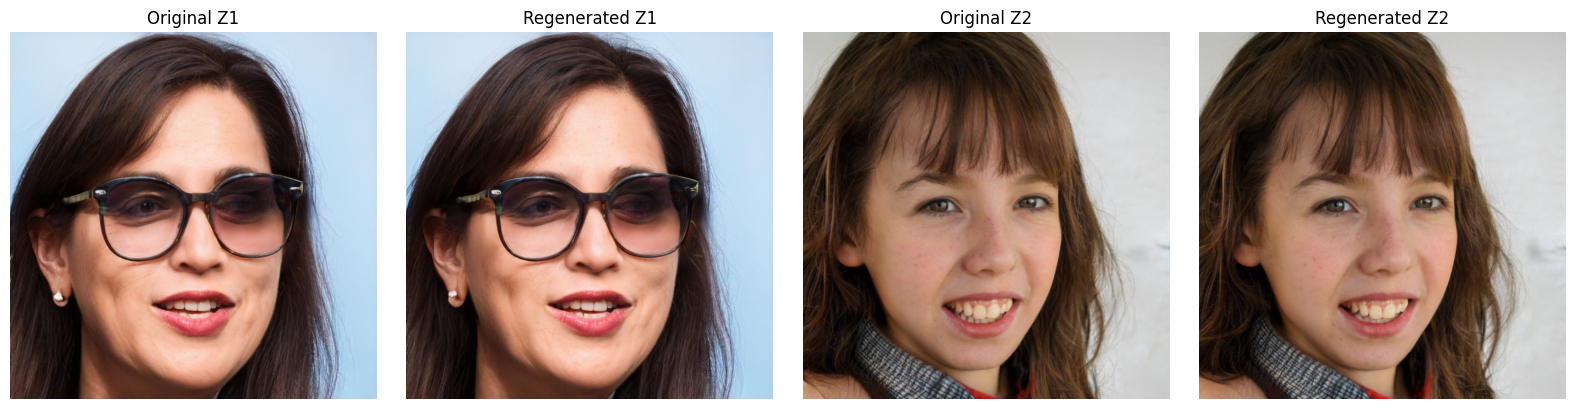

In [26]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(img1)
plt.axis("off")
plt.title("Original Z1")

plt.subplot(1, 4, 2)
plt.imshow(regenerated_img_z1)
plt.axis("off")
plt.title("Regenerated Z1")

plt.subplot(1, 4, 3)
plt.imshow(img2)
plt.axis("off")
plt.title("Original Z2")

plt.subplot(1, 4, 4)
plt.imshow(regenerated_img_z2)
plt.axis("off")
plt.title("Regenerated Z2")

plt.tight_layout()
plt.show()

## 27. Calculate the Difference Between the Two Images

In addition to visual comparison, we can calculate the numerical difference between the original and regenerated images.

If both images are identical, the pixel difference should be zero.

In [30]:
difference = np.abs(
    img1.astype(np.int16) -
    regenerated_img_z1.astype(np.int16)
)

print("Mean pixel difference:", difference.mean())
print("Maximum pixel difference:", difference.max())

Mean pixel difference: 6.461721738179524
Maximum pixel difference: 234


### Explanation

The absolute difference is calculated for every pixel.

Two values are reported:

- Mean pixel difference: average difference across all pixels.
- Maximum pixel difference: largest difference between corresponding pixels.

For a deterministic generation process using the same model and same latent vector, the values should normally be zero or extremely close to zero.

## 28. Experiment by Changing One Latent Dimension

The assignment also asks us to observe what happens when one or two dimensions of a latent vector are changed.

We first make a copy of `Z1`.

Then we change only the first latent dimension while keeping the other 511 dimensions unchanged.

In [31]:
Z1_one_dimension = Z1.copy()

# Change only the first latent dimension
Z1_one_dimension[0, 0] += 2.0

print("Original first dimension:", Z1[0, 0])
print("Modified first dimension:", Z1_one_dimension[0, 0])

Original first dimension: 0.49671414
Modified first dimension: 2.496714


### Explanation

`Z1.copy()` creates a separate copy of the original latent vector.

Only the first value is modified.

The remaining 511 values stay unchanged.

This allows us to investigate how a small change in the latent representation can affect the generated image.

## 29. Generate an Image After Changing One Dimension

In [32]:
z1_one_dimension = torch.from_numpy(
    Z1_one_dimension
).to(device)

with torch.no_grad():
    modified_output = G(
        z1_one_dimension,
        None
    )

modified_img = (
    modified_output.clamp(-1, 1) * 127.5 + 127.5
).to(torch.uint8)

modified_img = (
    modified_img[0]
    .permute(1, 2, 0)
    .cpu()
    .numpy()
)

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

## 30. Compare Original and One-Dimension Modified Images

The original image and the image produced after changing one latent dimension are displayed side by side.

The exact visual change depends on the selected latent dimension and the amount of modification.

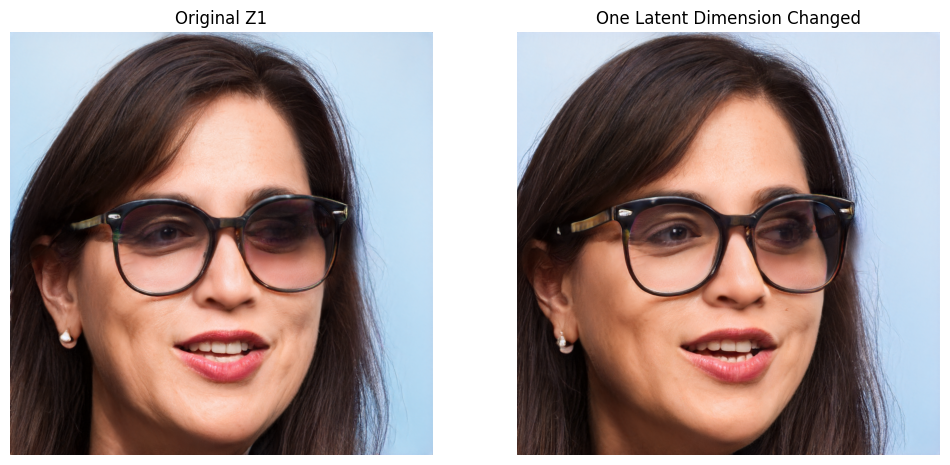

In [33]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.axis("off")
plt.title("Original Z1")

plt.subplot(1, 2, 2)
plt.imshow(modified_img)
plt.axis("off")
plt.title("One Latent Dimension Changed")

plt.show()

## 31. Experiment by Changing Two Latent Dimensions

We now change two dimensions of the original latent vector.

All other dimensions remain unchanged.

In [34]:
Z1_two_dimensions = Z1.copy()

# Change two latent dimensions
Z1_two_dimensions[0, 0] += 2.0
Z1_two_dimensions[0, 1] -= 2.0

print("Two latent dimensions were modified.")

Two latent dimensions were modified.


### Explanation

The first latent dimension is increased and the second latent dimension is decreased.

This creates another point in the latent space that is close to the original `Z1`, but not identical to it.

## 32. Generate an Image After Changing Two Dimensions

In [35]:
z1_two_dimensions = torch.from_numpy(
    Z1_two_dimensions
).to(device)

with torch.no_grad():
    modified_output_2 = G(
        z1_two_dimensions,
        None
    )

modified_img_2 = (
    modified_output_2.clamp(-1, 1) * 127.5 + 127.5
).to(torch.uint8)

modified_img_2 = (
    modified_img_2[0]
    .permute(1, 2, 0)
    .cpu()
    .numpy()
)

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

## 33. Compare Original and Two-Dimension Modified Images

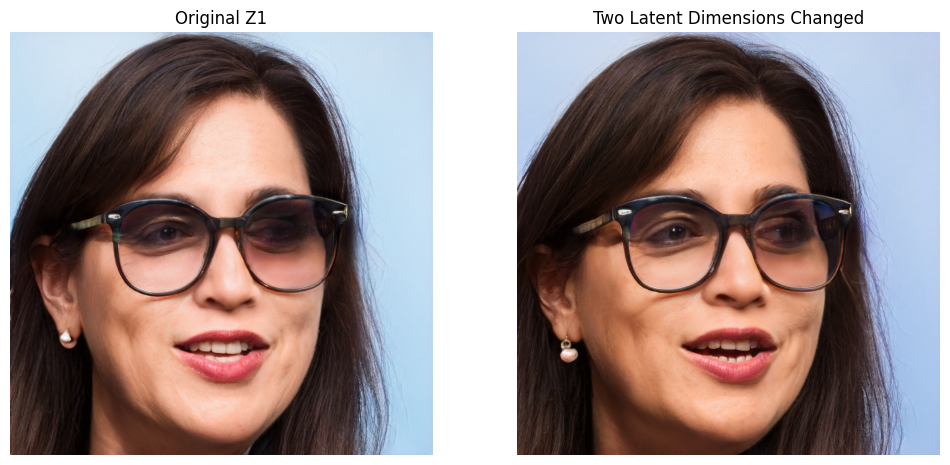

In [36]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.axis("off")
plt.title("Original Z1")

plt.subplot(1, 2, 2)
plt.imshow(modified_img_2)
plt.axis("off")
plt.title("Two Latent Dimensions Changed")

plt.show()

### Explanation

The two images are compared to observe the effect of modifying two latent dimensions.

The exact visible feature is not guaranteed to be the same for every dimension. StyleGAN2 distributes information across its latent representation, so multiple dimensions can contribute to a visual characteristic.

## 34. Save the Modified Images

The results from the latent-dimension experiments are saved for the final submission.

In [37]:
imageio.imwrite(
    f"{results_dir}/one_dimension_modified.png",
    modified_img
)

imageio.imwrite(
    f"{results_dir}/two_dimensions_modified.png",
    modified_img_2
)

print("Modified images saved successfully.")

Modified images saved successfully.


## 35. Final Comparison of Latent Space Experiments

This figure brings together the important results of the experiment:

1. Original image from Z1
2. Original image from Z2
3. Image after changing one latent dimension
4. Image after changing two latent dimensions

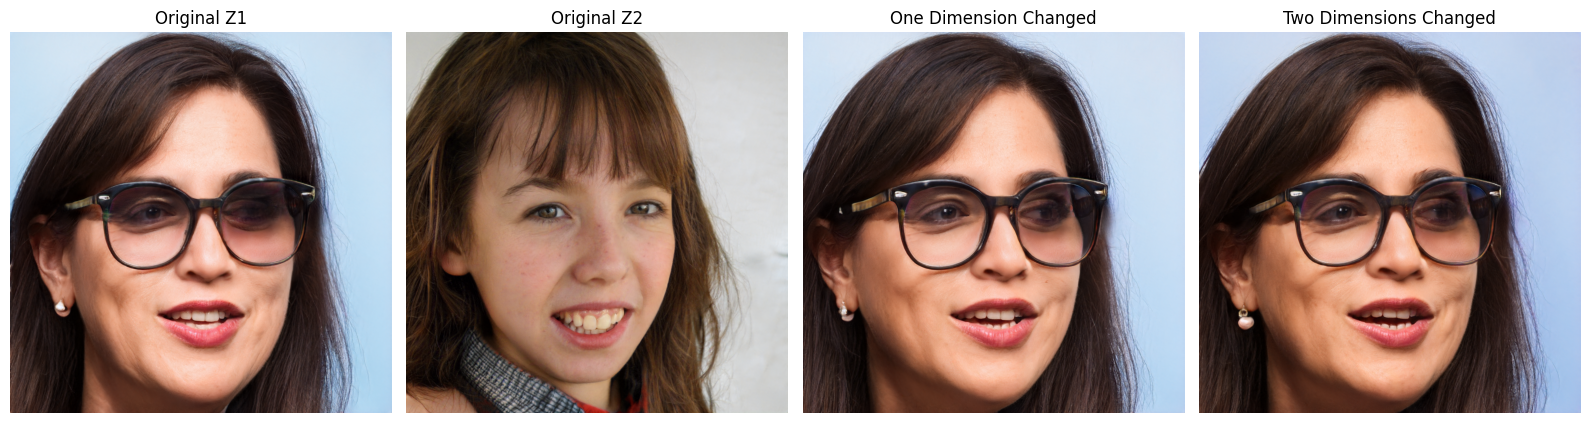

In [38]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(img1)
plt.axis("off")
plt.title("Original Z1")

plt.subplot(1, 4, 2)
plt.imshow(img2)
plt.axis("off")
plt.title("Original Z2")

plt.subplot(1, 4, 3)
plt.imshow(modified_img)
plt.axis("off")
plt.title("One Dimension Changed")

plt.subplot(1, 4, 4)
plt.imshow(modified_img_2)
plt.axis("off")
plt.title("Two Dimensions Changed")

plt.tight_layout()
plt.show()

# Observation

The pretrained StyleGAN2 model generated two different face images from the two random latent vectors Z1 and Z2. Since the latent vectors were different, the generated images also had different visual characteristics.

Linear interpolation between Z1 and Z2 produced intermediate latent vectors. The corresponding images showed a gradual transition from the first generated face to the second generated face. The changes were smooth instead of being completely different from one step to the next.

When the same latent vector Z1 was given to the generator again, the regenerated image was visually the same as the original image. This demonstrates that the pretrained generator produces a consistent output for the same latent vector during inference.

Changing one or two latent dimensions also changed the generated image. The exact visible change depends on the selected latent dimensions. A single dimension does not necessarily represent only one specific feature because visual information is distributed across the latent representation.

# What Changes Are Available Through the Latent Space?

The latent space allows us to explore different variations in the generated image. Moving between different latent vectors can change visual characteristics such as facial structure, hairstyle, pose, expression, and other appearance-related features.

Linear interpolation shows that the generator can create a smooth transition between two different generated images.

Changing selected latent dimensions can also produce changes in the generated image. However, the exact feature affected depends on the latent dimension and the direction of the change.

Therefore, the latent space provides a way to control and explore variations in generated images without retraining the StyleGAN2 model.

# Conclusion

In this experiment, a pretrained StyleGAN2 model was successfully used to explore its latent space. Two random latent vectors, Z1 and Z2, were generated and used to produce two different images.

Linear interpolation was then performed between Z1 and Z2. Ten intermediate latent vectors were generated, and the corresponding images demonstrated a smooth visual transition between the two original images.

The original image was also generated again using the same latent vector. The regenerated image was visually identical to the original, showing the consistent behavior of the generator during inference.

Finally, one and two latent dimensions were modified to observe changes in the generated image. The experiment demonstrated that changes in the latent space can produce meaningful visual variations in the generated output.

Overall, this experiment shows that the latent space of StyleGAN2 provides a powerful way to explore and control variations in generated images without training the model from scratch.